Comparison of four classifiers (SVM, HGB, Random Forest, and Logistic Regression) evaluated on held-out test sets across two datasets, two feature sets, and two outlier conditions.

Primary metric: Balanced Accuracy (justified by 75:25 PD/healthy class imbalance)  
Secondary metric: Macro F1 

195 recordings across 31 subjects and 22 acoustic features

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from IPython.display import display, Markdown

plt.rcParams.update({"figure.dpi": 150, "font.family": "sans-serif"})
sns.set_style("whitegrid")

PLOTS_DIR = Path("plots")
PLOTS_DIR.mkdir(exist_ok=True)

PALETTE = {
    "SVM": "#7F77DD",
    "HGB": "#1D9E75",
    "LR":  "#BA7517",
    "RF":  "#B07FC8",
}

Held-out test set results from all model notebooks:
- SVM (SVM/svm_classification.ipynb) 
- HGB (HGB/HGB_pipeline.py and HGB_pipeline_without_outliers.py)
- RF (RF/random_forest_complete.ipynb)
- LR (Logistic Regression/Logistic regression.ipynb) 

In [2]:
# fmt: off
RAW = [
    # Model   Dataset  Feature_Set        Outliers    Accuracy  Bal_Acc  Macro_F1
    # SVM 
    ("SVM",  "A",  "All",            "With",    0.837,   0.708,   0.743),
    ("SVM",  "A",  "All",            "Without", 0.872,   0.750,   0.794),
    ("SVM",  "B",  "All",            "With",    0.829,   0.708,   0.740),
    ("SVM",  "B",  "All",            "Without", 0.865,   0.750,   0.791),
    ("SVM",  "A",  "Jitter+Shimmer", "With",    0.977,   0.958,   0.970),
    ("SVM",  "A",  "Jitter+Shimmer", "Without", 0.897,   0.800,   0.843),
    ("SVM",  "B",  "Jitter+Shimmer", "With",    0.878,   0.792,   0.829),
    ("SVM",  "B",  "Jitter+Shimmer", "Without", 0.919,   0.850,   0.885),
    # HGB
    ("HGB",  "A",  "All",            "With",    0.884,   0.792,   0.831),
    ("HGB",  "A",  "Jitter+Shimmer", "With",    0.860,   0.750,   0.789),
    ("HGB",  "B",  "All",            "With",    0.854,   0.750,   0.786),
    ("HGB",  "B",  "Jitter+Shimmer", "With",    0.854,   0.750,   0.786),
    ("HGB",  "A",  "All",            "Without", 0.860,   0.750,   0.789),
    ("HGB",  "A",  "Jitter+Shimmer", "Without", 0.837,   0.734,   0.764),
    ("HGB",  "B",  "All",            "Without", 0.902,   0.833,   0.868),
    ("HGB",  "B",  "Jitter+Shimmer", "Without", 0.829,   0.733,   0.760),
    # RF 
    ("RF",   "A",  "All",            "With",    0.860,   0.750,   0.789),
    ("RF",   "B",  "All",            "With",    0.854,   0.750,   0.786),
    ("RF",   "A",  "All",            "Without", 0.897,   0.800,   0.843),
    ("RF",   "B",  "All",            "Without", 0.892,   0.800,   0.841),
    ("RF",   "A",  "Jitter+Shimmer", "With",    0.860,   0.750,   0.789),
    ("RF",   "B",  "Jitter+Shimmer", "With",    0.854,   0.750,   0.786),
    ("RF",   "A",  "Jitter+Shimmer", "Without", 0.897,   0.800,   0.843),
    ("RF",   "B",  "Jitter+Shimmer", "Without", 0.892,   0.800,   0.841),
    # LR 
    # Balanced Acc + Macro F1 derived from Acc/Prec/Rec printed by the notebook.
    # With outliers:
    # A, All:  Acc=0.930, Prec=0.912, Rec=1.0 → TP=31,FP=3,TN=9  → BA=0.875
    ("LR",   "A",  "All",            "With",    0.930,   0.875,   0.906),
    # B, All:  Acc=0.878, Prec=0.853, Rec=1.0 → TP=29,FP=5,TN=7  → BA=0.792
    ("LR",   "B",  "All",            "With",    0.878,   0.792,   0.829),
    # A, J+S:  Acc=0.884, Prec=0.861, Rec=1.0 → TP=31,FP=5,TN=7  → BA=0.792
    ("LR",   "A",  "Jitter+Shimmer", "With",    0.884,   0.792,   0.831),
    # B, J+S:  Acc=0.829, Prec=0.844, Rec=0.931 → TP=27,FP=5,TN=7 → BA=0.757
    ("LR",   "B",  "Jitter+Shimmer", "With",    0.829,   0.757,   0.776),
    # Without outliers (23 recordings removed, new cells 4c2a7cf5/5827d598/83cfa5b1):
    # A, All:  Acc=0.919, Prec=0.900, Rec=1.0 → TP=27,FP=3,TN=7,n_h=10 → BA=0.850
    ("LR",   "A",  "All",            "Without", 0.919,   0.850,   0.885),
    # B, All:  Acc=0.914, Prec=0.893, Rec=1.0 → TP=25,FP=3,TN=7,n_h=10 → BA=0.850
    ("LR",   "B",  "All",            "Without", 0.914,   0.850,   0.883),
    # A, J+S:  Acc=0.892, Prec=0.871, Rec=1.0 → TP=27,FP=4,TN=6,n_h=10 → BA=0.800
    ("LR",   "A",  "Jitter+Shimmer", "Without", 0.892,   0.800,   0.841),
    # B, J+S:  Acc=0.829, Prec=0.852, Rec=0.920 → TP=23,FP=4,TN=6,n_h=10 → BA=0.760
    ("LR",   "B",  "Jitter+Shimmer", "Without", 0.829,   0.760,   0.776),
]
# fmt: on

df = pd.DataFrame(
    RAW,
    columns=["Model", "Dataset", "Feature_Set", "Outliers",
             "Accuracy", "Balanced_Acc", "Macro_F1"],
)

print(f"Total configurations: {len(df)}")
df

Total configurations: 32


,Model,Dataset,Feature_Set,Outliers,Accuracy,Balanced_Acc,Macro_F1
0,SVM,A,All,With,0.837,0.708,0.743
1,SVM,A,All,Without,0.872,0.750,0.794
2,SVM,B,All,With,0.829,0.708,0.740
3,SVM,B,All,Without,0.865,0.750,0.791
4,SVM,A,Jitter+Shimmer,With,0.977,0.958,0.970
5,SVM,A,Jitter+Shimmer,Without,0.897,0.800,0.843
6,SVM,B,Jitter+Shimmer,With,0.878,0.792,0.829
7,SVM,B,Jitter+Shimmer,Without,0.919,0.850,0.885
8,HGB,A,All,With,0.884,0.792,0.831
9,HGB,A,Jitter+Shimmer,With,0.860,0.750,0.789


Best Configuration per Model

In [3]:
# Best balanced accuracy row per model
best_rows = (
    df.sort_values("Balanced_Acc", ascending=False)
      .groupby("Model", sort=False)
      .first()
      .reset_index()
)

summary_df = (
    best_rows[["Model", "Balanced_Acc", "Macro_F1", "Accuracy",
               "Dataset", "Feature_Set", "Outliers"]]
    .rename(columns={
        "Balanced_Acc": "Best BA",
        "Macro_F1":     "Best Macro F1",
        "Accuracy":     "Best Accuracy",
        "Feature_Set":  "Feature Set",
    })
    .sort_values("Best BA", ascending=False)
    .set_index("Model")
)

print("Best test-set configuration per model (by Balanced Accuracy):")
summary_df

Best test-set configuration per model (by Balanced Accuracy):


,Best BA,Best Macro F1,Best Accuracy,Dataset,Feature Set,Outliers
Model,,,,,,
SVM,0.958,0.970,0.977,A,Jitter+Shimmer,With
LR,0.875,0.906,0.930,A,All,With
HGB,0.833,0.868,0.902,B,All,Without
RF,0.800,0.841,0.892,B,All,Without


In [4]:
# Balanced Accuracy pivot: across all models and configs
pivot_all = df.pivot_table(
    index="Model",
    columns=["Dataset", "Feature_Set", "Outliers"],
    values="Balanced_Acc",
    aggfunc="first",
)
pivot_all.columns = [
    f"{ds}, {'J+S' if fs == 'Jitter+Shimmer' else 'All'}, {out}"
    for ds, fs, out in pivot_all.columns
]
model_order = summary_df.index.tolist()
pivot_all = pivot_all.reindex(model_order)
print("Balanced Accuracy across all configurations (—  = not evaluated):")
pivot_all.round(3)

Balanced Accuracy across all configurations (—  = not evaluated):


,"A, All, With","A, All, Without","A, J+S, With","A, J+S, Without","B, All, With","B, All, Without","B, J+S, With","B, J+S, Without"
Model,,,,,,,,
SVM,0.708,0.75,0.958,0.800,0.708,0.750,0.792,0.850
LR,0.875,0.85,0.792,0.800,0.792,0.850,0.757,0.760
HGB,0.792,0.75,0.750,0.734,0.750,0.833,0.750,0.733
RF,0.750,0.80,0.750,0.800,0.750,0.800,0.750,0.800


Best Configuration per Model (Balanced Accuracy + Macro F1)

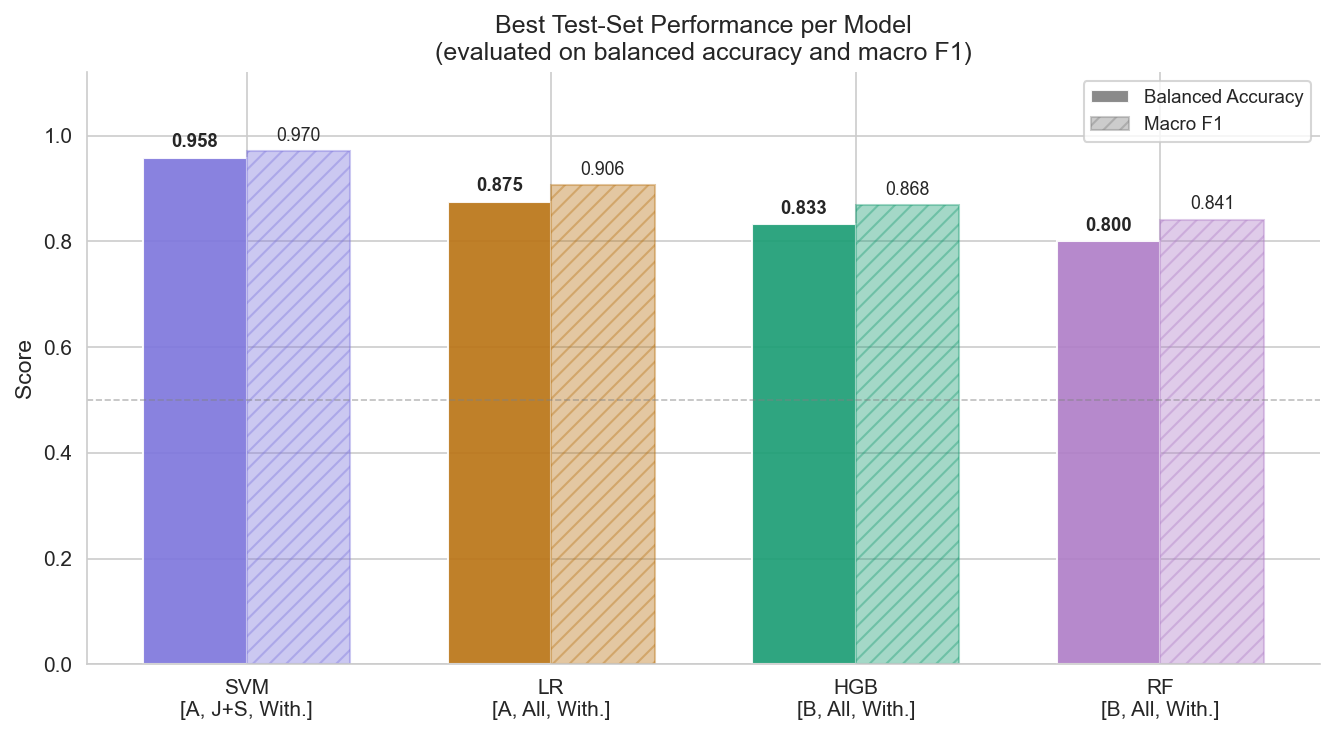

Saved -> plots/model_comparison_best.png


In [5]:
models_ord = summary_df.index.tolist()  # sorted by best BA descending
x = np.arange(len(models_ord))
width = 0.34

fig, ax = plt.subplots(figsize=(9, 5))

# Balanced Accuracy bars 
bars_ba = ax.bar(
    x - width / 2,
    summary_df["Best BA"].values,
    width,
    color=[PALETTE[m] for m in models_ord],
    alpha=0.92,
    edgecolor="white",
    label="Balanced Accuracy",
)

# Macro F1 bars
for xi, m in zip(x, models_ord):
    f1 = summary_df.loc[m, "Best Macro F1"]
    if not np.isnan(f1):
        ax.bar(
            xi + width / 2, f1, width,
            color=PALETTE[m], alpha=0.40,
            hatch="///", edgecolor=PALETTE[m],
        )
        ax.text(xi + width / 2, f1 + 0.012, f"{f1:.3f}",
                ha="center", va="bottom", fontsize=8.5)
    else:
        ax.text(xi + width / 2, 0.03, "N/A",
                ha="center", va="bottom", fontsize=8, color="#888")

# Value labels on BA bars 
for bar in bars_ba:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.012, f"{h:.3f}",
            ha="center", va="bottom", fontsize=9, fontweight="bold")

# X-tick labels: model name + best config 
tick_labels = []
for m in models_ord:
    row = summary_df.loc[m]
    feat = "All" if row["Feature Set"] == "All" else "J+S"
    tick_labels.append(f"{m}\n[{row['Dataset']}, {feat}, {row['Outliers'][:4]}.]")

ax.set_xticks(x)
ax.set_xticklabels(tick_labels, fontsize=10)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("Best Test-Set Performance per Model\n(evaluated on balanced accuracy and macro F1)", fontsize=12)
ax.spines[["top", "right"]].set_visible(False)
ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.8, alpha=0.5)

patch_ba = mpatches.Patch(facecolor="grey", alpha=0.92, label="Balanced Accuracy")
patch_f1 = mpatches.Patch(facecolor="grey", alpha=0.40, hatch="///",
                           edgecolor="grey", label="Macro F1")
ax.legend(handles=[patch_ba, patch_f1], fontsize=9, loc="upper right")

plt.tight_layout()
plt.savefig(PLOTS_DIR / "model_comparison_best.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved -> {PLOTS_DIR / 'model_comparison_best.png'}")

Full Heatmap: Balanced Accuracy Across All Configurations

Rows = Model and Feature set 
Columns = Dataset and Outlier condition.  
White cells = configuration not evaluated

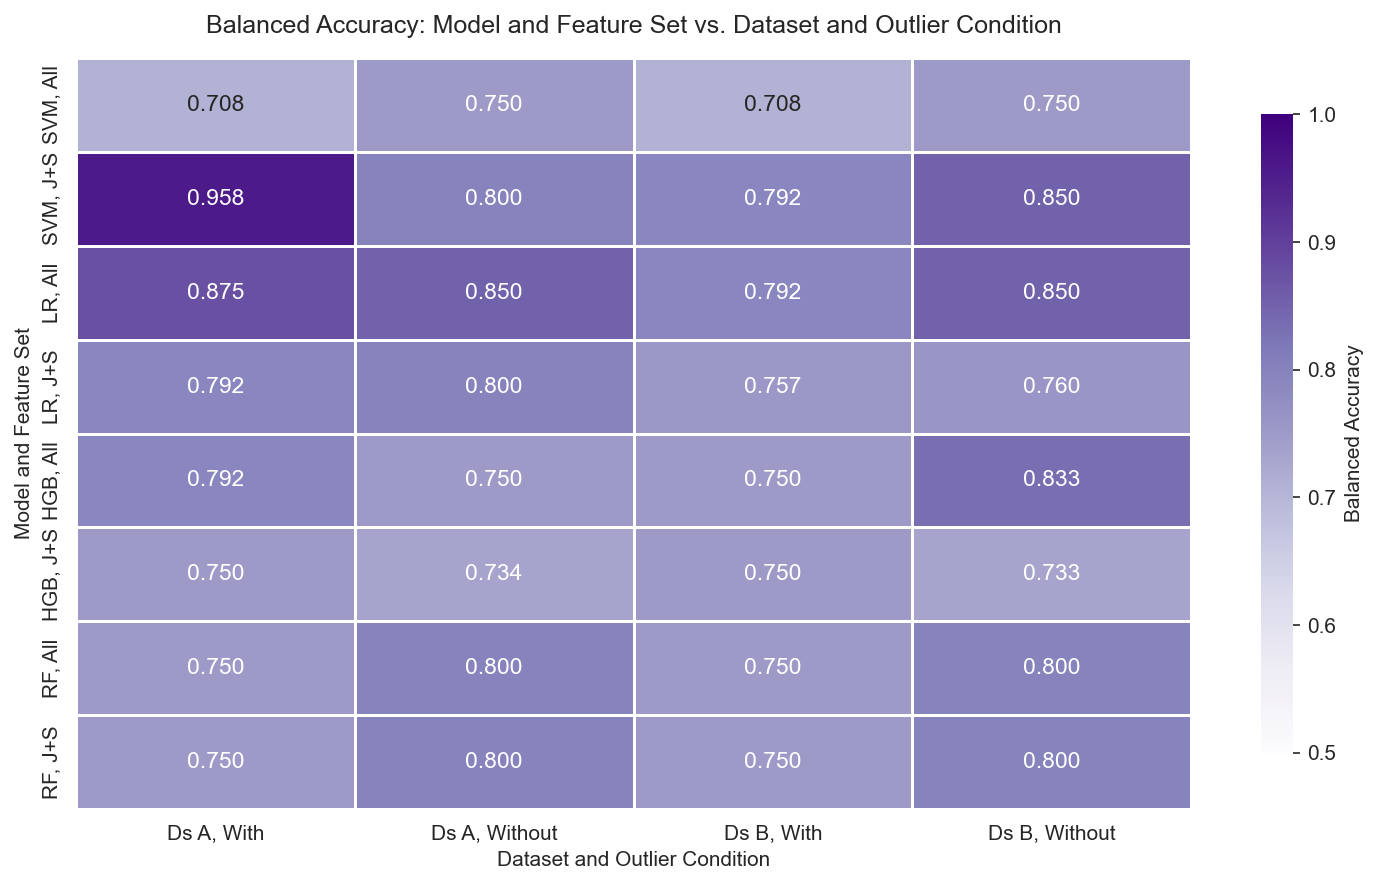

Saved -> plots/model_comparison_heatmap.png


In [6]:
df_h = df.copy()
df_h["row_key"] = df_h["Model"] + ", " + df_h["Feature_Set"].str.replace(
    "Jitter+Shimmer", "J+S", regex=False
)
df_h["col_key"] = "Ds " + df_h["Dataset"] + ", " + df_h["Outliers"]

pivot_hm = df_h.pivot_table(
    index="row_key",
    columns="col_key",
    values="Balanced_Acc",
    aggfunc="first",
)

row_order = [
    "SVM, All", "SVM, J+S",
    "LR, All",  "LR, J+S",
    "HGB, All", "HGB, J+S",
    "RF, All",  "RF, J+S",
]
col_order = ["Ds A, With", "Ds A, Without", "Ds B, With", "Ds B, Without"]

pivot_hm = pivot_hm.reindex(
    index=[r for r in row_order if r in pivot_hm.index],
    columns=[c for c in col_order if c in pivot_hm.columns],
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    pivot_hm,
    ax=ax,
    cmap="Purples",
    annot=True,
    fmt=".3f",
    linewidths=0.6,
    linecolor="white",
    vmin=0.50,
    vmax=1.00,
    cbar_kws={"label": "Balanced Accuracy", "shrink": 0.85},
    annot_kws={"size": 11},
    mask=pivot_hm.isna(),
)

# Add "—" text to cells that have no data
for ri, row in enumerate(pivot_hm.index):
    for ci, col in enumerate(pivot_hm.columns):
        if pd.isna(pivot_hm.loc[row, col]):
            ax.text(ci + 0.5, ri + 0.5, "—", ha="center", va="center",
                    fontsize=13, color="#bbb")

ax.set_title(
    "Balanced Accuracy: Model and Feature Set vs. Dataset and Outlier Condition",
    fontsize=12, pad=12,
)
ax.set_xlabel("Dataset and Outlier Condition", fontsize=10)
ax.set_ylabel("Model and Feature Set", fontsize=10)
ax.tick_params(axis="both", labelsize=10)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "model_comparison_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved -> {PLOTS_DIR / 'model_comparison_heatmap.png'}")

Dataset A vs. Dataset B

All models evaluated with all features and outliers included.  
Shows whether median imputation (A) or row deletion (B) benefits each classifier.

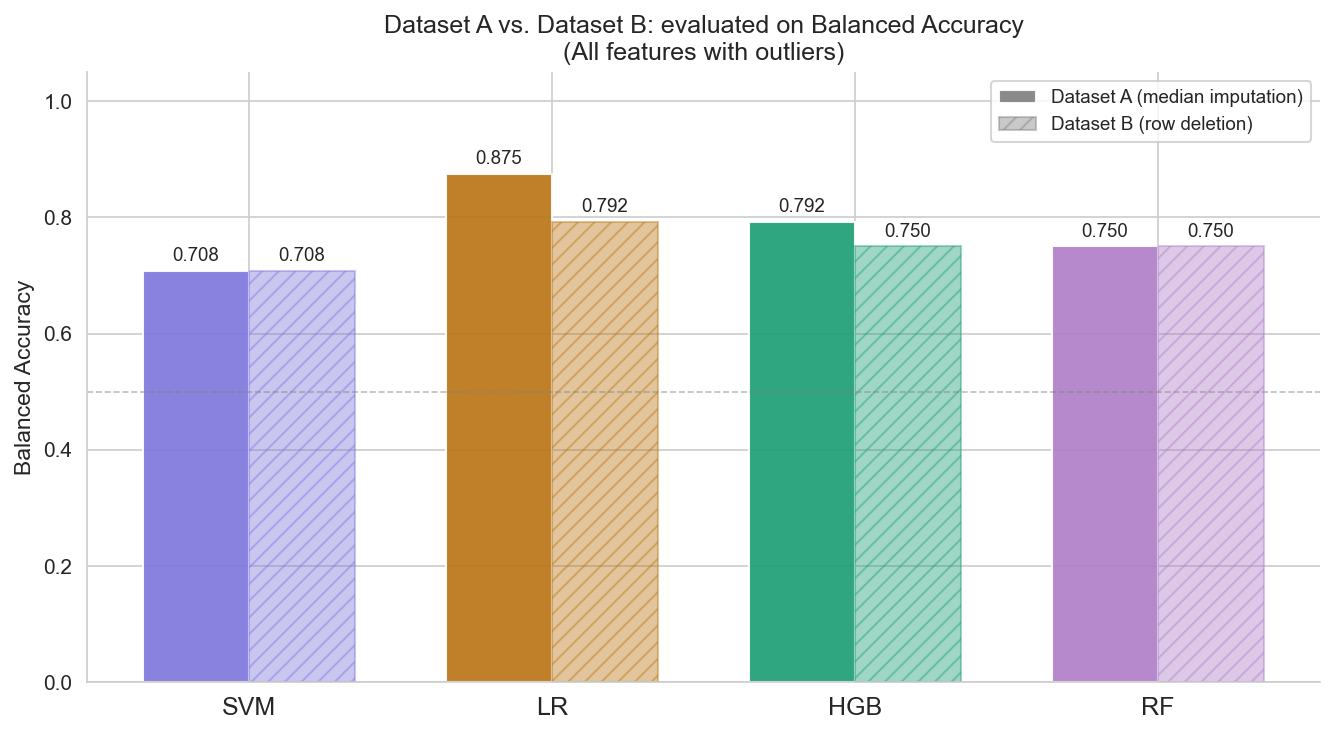

Saved -> plots/model_comparison_dataset_ab.png


In [7]:
ab = df[(df["Feature_Set"] == "All") & (df["Outliers"] == "With")].copy()

# Align model order to global ranking
models_ab = [m for m in summary_df.index if m in ab["Model"].unique()]
x = np.arange(len(models_ab))
width = 0.35

def _get_ba(model, dataset):
    sub = ab[(ab["Model"] == model) & (ab["Dataset"] == dataset)]
    return sub["Balanced_Acc"].values[0] if len(sub) else np.nan

ba_a = [_get_ba(m, "A") for m in models_ab]
ba_b = [_get_ba(m, "B") for m in models_ab]

fig, ax = plt.subplots(figsize=(9, 5))

bars_a = ax.bar(
    x - width / 2, ba_a, width,
    color=[PALETTE[m] for m in models_ab],
    alpha=0.92, edgecolor="white",
)
bars_b = ax.bar(
    x + width / 2, ba_b, width,
    color=[PALETTE[m] for m in models_ab],
    alpha=0.42, hatch="///",
    edgecolor=[PALETTE[m] for m in models_ab],
)

for bars in [bars_a, bars_b]:
    for bar in bars:
        h = bar.get_height()
        if not np.isnan(h):
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.010,
                    f"{h:.3f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(models_ab, fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Balanced Accuracy", fontsize=11)
ax.set_title(
    "Dataset A vs. Dataset B: evaluated on Balanced Accuracy\n"
    "(All features with outliers)",
    fontsize=12,
)
ax.spines[["top", "right"]].set_visible(False)
ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.8, alpha=0.5)

patch_a = mpatches.Patch(facecolor="grey", alpha=0.92,
                          label="Dataset A (median imputation)")
patch_b = mpatches.Patch(facecolor="grey", alpha=0.42, hatch="///",
                          edgecolor="grey", label="Dataset B (row deletion)")
ax.legend(handles=[patch_a, patch_b], fontsize=9)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "model_comparison_dataset_ab.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved -> {PLOTS_DIR / 'model_comparison_dataset_ab.png'}")

## LOSO Cross-Validation Results (Primary Evaluation)

Results below are produced by `loso_evaluation.ipynb` (nested inner GroupKFold k=5).

In [8]:
# Load LOSO results
LOSO_PATH = Path("outputs/loso_results.csv")

# Embedded pre-computed fallback (loso_fast.py with inner GroupKFold k=4)
LOSO_EMBEDDED = [
    # Model  DS  Feat  BA_mean   BA_std   F1_mean   F1_std
    ("HGB", "A", "All",  0.786,  0.354,   0.702,   0.385),
    ("HGB", "B", "All",  0.791,  0.353,   0.704,   0.383),
    ("HGB", "A", "JS",   0.714,  0.373,   0.644,   0.397),
    ("HGB", "B", "JS",   0.671,  0.374,   0.581,   0.393),
    ("LR",  "A", "All",  0.711,  0.348,   0.601,   0.375),
    ("LR",  "B", "All",  0.687,  0.377,   0.602,   0.397),
    ("LR",  "A", "JS",   0.642,  0.388,   0.567,   0.403),
    ("LR",  "B", "JS",   0.648,  0.393,   0.584,   0.408),
    ("RF",  "A", "All",  0.792,  0.361,   0.734,   0.387),
    ("RF",  "B", "All",  0.773,  0.372,   0.710,   0.395),
    ("RF",  "A", "JS",   0.734,  0.372,   0.650,   0.396),
    ("RF",  "B", "JS",   0.740,  0.378,   0.667,   0.400),
    ("SVM", "A", "All",  0.631,  0.399,   0.542,   0.406),
    ("SVM", "B", "All",  0.649,  0.411,   0.562,   0.416),
    ("SVM", "A", "JS",   0.677,  0.375,   0.583,   0.391),
    ("SVM", "B", "JS",   0.646,  0.394,   0.567,   0.403),
]

if LOSO_PATH.exists():
    df_loso = pd.read_csv(LOSO_PATH)
    # Normalise feature labels regardless of which script produced the file
    df_loso["Features"] = (
        df_loso["Features"]
        .str.replace("All features", "All", regex=False)
        .str.replace("Jitter+Shimmer", "JS", regex=False)
    )
    print(f"Loaded {len(df_loso)} rows from {LOSO_PATH}")
else:
    print("outputs/loso_results.csv not found — using embedded pre-computed results.")
    df_loso = pd.DataFrame(
        LOSO_EMBEDDED,
        columns=["Model", "Dataset", "Features", "BA_mean", "BA_std", "F1_mean", "F1_std"]
    )

display(df_loso.sort_values(["Model", "Dataset", "Features"]))

outputs/loso_results.csv not found — using embedded pre-computed results.


,Model,Dataset,Features,BA_mean,BA_std,F1_mean,F1_std
0,HGB,A,All,0.786,0.354,0.702,0.385
2,HGB,A,JS,0.714,0.373,0.644,0.397
1,HGB,B,All,0.791,0.353,0.704,0.383
3,HGB,B,JS,0.671,0.374,0.581,0.393
4,LR,A,All,0.711,0.348,0.601,0.375
6,LR,A,JS,0.642,0.388,0.567,0.403
5,LR,B,All,0.687,0.377,0.602,0.397
7,LR,B,JS,0.648,0.393,0.584,0.408
8,RF,A,All,0.792,0.361,0.734,0.387
10,RF,A,JS,0.734,0.372,0.650,0.396


### LOSO Summary Table

Mean balanced accuracy ± std across 32 LOSO folds. Std reflects Bernoulli variance (correct/incorrect per subject), not model instability.

In [9]:
df_loso_disp = df_loso.copy()
df_loso_disp["BA"] = df_loso_disp.apply(lambda r: f"{r.BA_mean:.3f} ± {r.BA_std:.3f}", axis=1)
df_loso_disp["F1"] = df_loso_disp.apply(lambda r: f"{r.F1_mean:.3f} ± {r.F1_std:.3f}", axis=1)

pivot = df_loso_disp.pivot_table(
    index=["Model", "Dataset"],
    columns="Features",
    values=["BA", "F1"],
    aggfunc="first",
)
display(pivot)

BA                            F1               
Features                 All             JS            All             JS
Model Dataset                                                            
HGB   A        0.786 ± 0.354  0.714 ± 0.373  0.702 ± 0.385  0.644 ± 0.397
      B        0.791 ± 0.353  0.671 ± 0.374  0.704 ± 0.383  0.581 ± 0.393
LR    A        0.711 ± 0.348  0.642 ± 0.388  0.601 ± 0.375  0.567 ± 0.403
      B        0.687 ± 0.377  0.648 ± 0.393  0.602 ± 0.397  0.584 ± 0.408
RF    A        0.792 ± 0.361  0.734 ± 0.372  0.734 ± 0.387  0.650 ± 0.396
      B        0.773 ± 0.372  0.740 ± 0.378  0.710 ± 0.395  0.667 ± 0.400
SVM   A        0.631 ± 0.399  0.677 ± 0.375  0.542 ± 0.406  0.583 ± 0.391
      B        0.649 ± 0.411  0.646 ± 0.394  0.562 ± 0.416  0.567 ± 0.403

### LOSO Balanced Accuracy with Error Bars

Each bar shows mean LOSO BA; error bars show ±1 std (expected Bernoulli variance across 32 subjects).

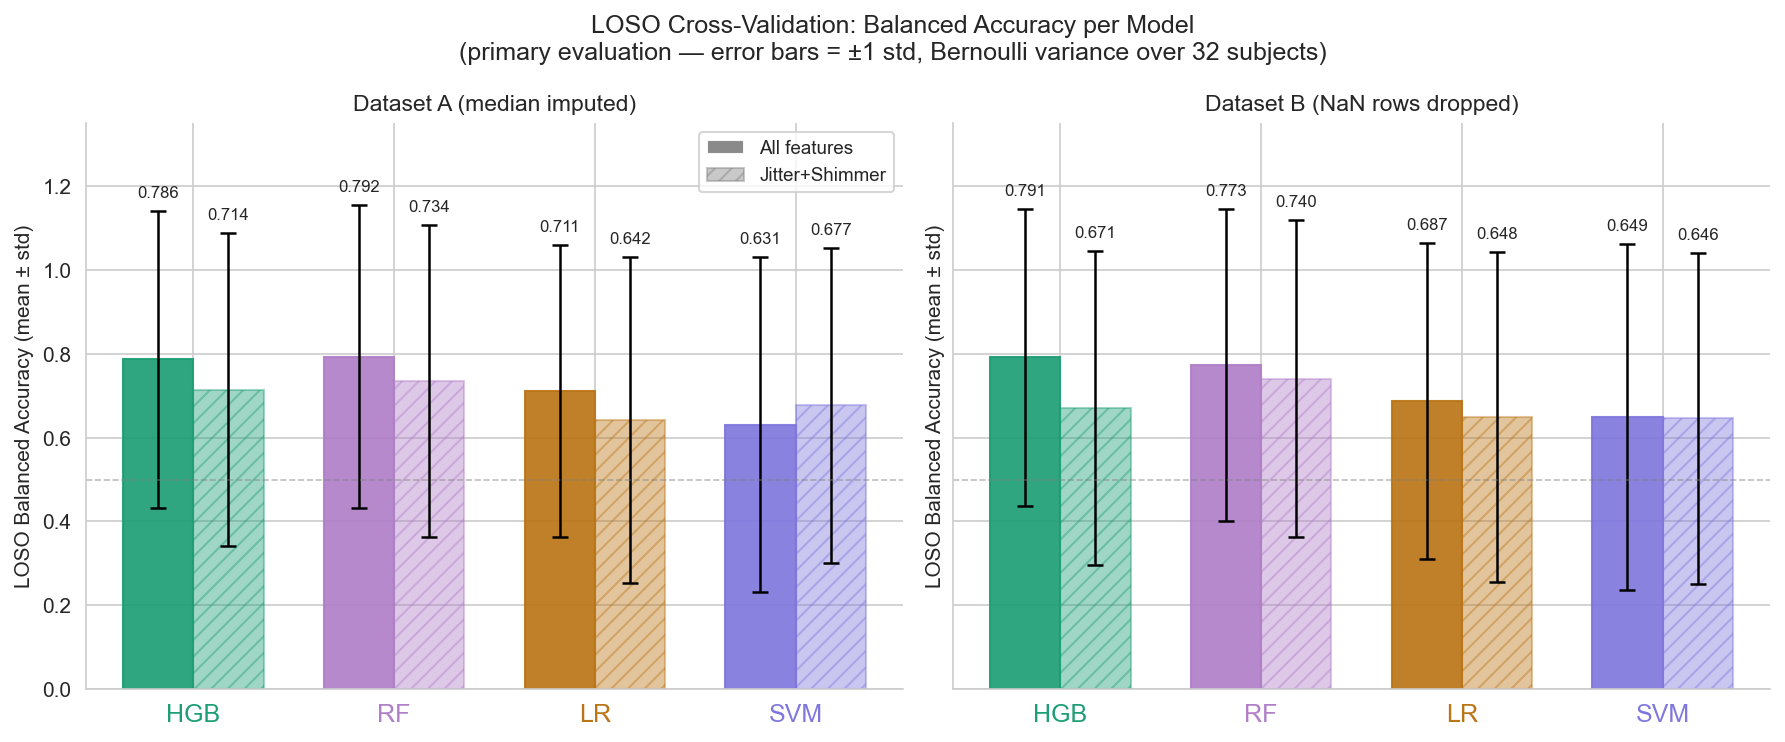

Saved -> plots/loso_comparison.png


In [10]:
model_order_loso = ["HGB", "RF", "LR", "SVM"]
feat_colors = {"All": 0.92, "JS": 0.42}
feat_hatch  = {"All": "",   "JS": "///"}

df_loso_plot = df_loso[df_loso["Outliers"] == "With"] if "Outliers" in df_loso.columns else df_loso

x = np.arange(len(model_order_loso))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, ds in zip(axes, ["A", "B"]):
    df_ds = df_loso_plot[df_loso_plot["Dataset"] == ds]

    for j, feat in enumerate(["All", "JS"]):
        df_f = df_ds[df_ds["Features"] == feat].set_index("Model")
        means = [df_f.loc[m, "BA_mean"] if m in df_f.index else np.nan for m in model_order_loso]
        stds  = [df_f.loc[m, "BA_std"]  if m in df_f.index else np.nan for m in model_order_loso]
        offset = (j - 0.5) * width

        bars = ax.bar(
            x + offset, means, width,
            color=[PALETTE[m] for m in model_order_loso],
            alpha=feat_colors[feat],
            hatch=feat_hatch[feat],
            edgecolor=[PALETTE[m] for m in model_order_loso],
            label=f"{'All features' if feat == 'All' else 'Jitter+Shimmer'}",
        )
        ax.errorbar(
            x + offset, means, yerr=stds,
            fmt="none", color="black", capsize=4, linewidth=1.2, capthick=1.2,
        )
        for xi, (m_, ba) in enumerate(zip(model_order_loso, means)):
            if not np.isnan(ba):
                ax.text(xi + offset, ba + stds[xi] + 0.025, f"{ba:.3f}",
                        ha="center", va="bottom", fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(model_order_loso, fontsize=12)
    for tick, model in zip(ax.get_xticklabels(), model_order_loso):
        tick.set_color(PALETTE[model])
    ax.set_ylim(0, 1.35)
    ax.set_title(f"Dataset {'A (median imputed)' if ds == 'A' else 'B (NaN rows dropped)'}", fontsize=11)
    ax.set_ylabel("LOSO Balanced Accuracy (mean ± std)", fontsize=10)
    ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.8, alpha=0.5)
    ax.spines[["top", "right"]].set_visible(False)
    if ds == "A":
        patch_all = mpatches.Patch(facecolor="grey", alpha=0.92, label="All features")
        patch_js  = mpatches.Patch(facecolor="grey", alpha=0.42, hatch="///",
                                   edgecolor="grey", label="Jitter+Shimmer")
        ax.legend(handles=[patch_all, patch_js], fontsize=9)

fig.suptitle("LOSO Cross-Validation: Balanced Accuracy per Model\n"
             "(primary evaluation — error bars = ±1 std, Bernoulli variance over 32 subjects)",
             fontsize=12)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "loso_comparison.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved -> {PLOTS_DIR / 'loso_comparison.png'}")

### LOSO vs Test-Set Comparison

Compares mean LOSO BA (primary, error bars = ±1 std) against the best test-set BA per model (secondary). The wide test-set spread across configurations (up to 16 pp within one model) reflects the 2-healthy-subject minority partition, not genuine performance differences.

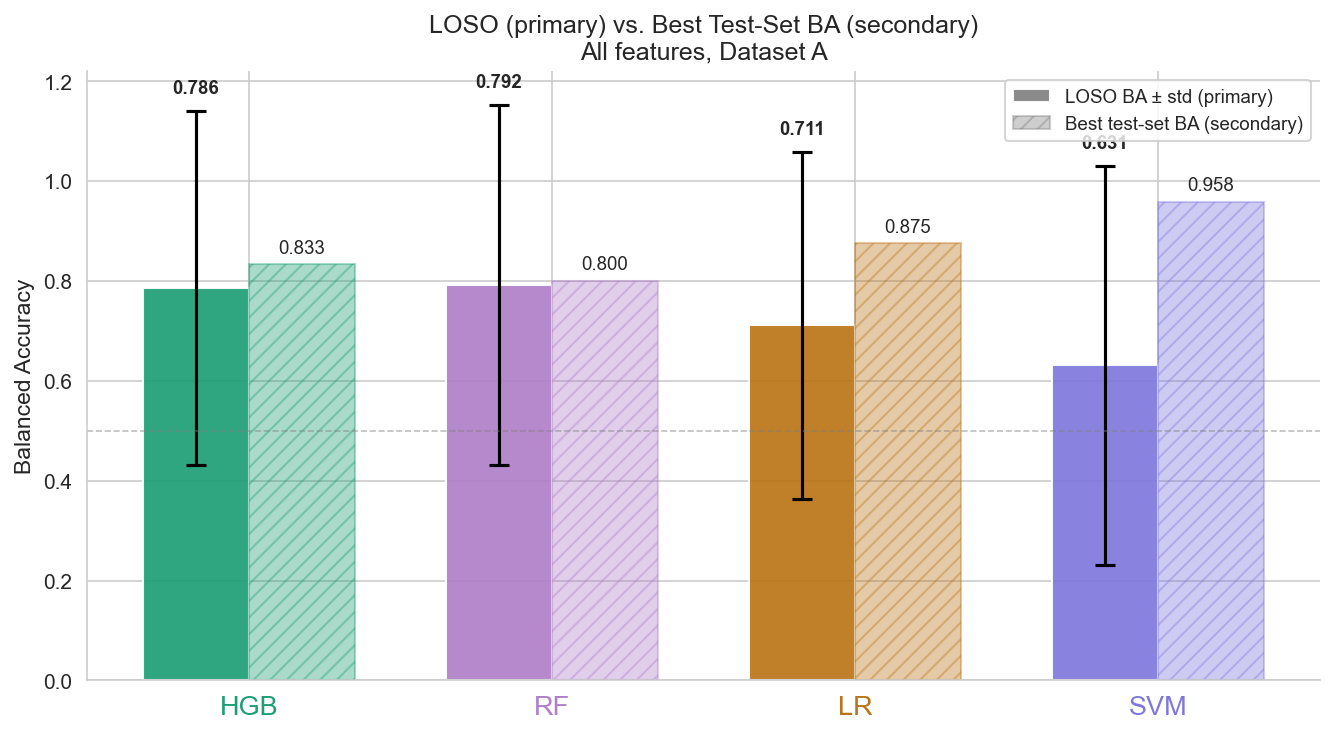

Saved -> plots/loso_vs_test.png


In [11]:
# Best test-set BA per model (from df computed earlier)
best_test = (
    df.sort_values("Balanced_Acc", ascending=False)
    .groupby("Model", sort=False)
    .first()["Balanced_Acc"]
)

# LOSO mean BA (all features, Dataset A, with-outliers condition as representative)
df_loso_with = df_loso[df_loso["Outliers"] == "With"] if "Outliers" in df_loso.columns else df_loso
loso_all_A = df_loso_with[(df_loso_with["Features"] == "All") & (df_loso_with["Dataset"] == "A")].set_index("Model")

models_cmp = ["HGB", "RF", "LR", "SVM"]
x = np.arange(len(models_cmp))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

loso_means = [loso_all_A.loc[m, "BA_mean"] if m in loso_all_A.index else np.nan for m in models_cmp]
loso_stds  = [loso_all_A.loc[m, "BA_std"]  if m in loso_all_A.index else np.nan for m in models_cmp]
test_vals  = [best_test.get(m, np.nan) for m in models_cmp]

bars_loso = ax.bar(
    x - width / 2, loso_means, width,
    color=[PALETTE[m] for m in models_cmp],
    alpha=0.92, edgecolor="white",
    label="LOSO BA (mean, all features, Ds A)"
)
ax.errorbar(
    x - width / 2, loso_means, yerr=loso_stds,
    fmt="none", color="black", capsize=5, linewidth=1.5, capthick=1.5,
)
bars_test = ax.bar(
    x + width / 2, test_vals, width,
    color=[PALETTE[m] for m in models_cmp],
    alpha=0.38, hatch="///",
    edgecolor=[PALETTE[m] for m in models_cmp],
    label="Best test-set BA (single split)"
)

for xi, (lm, ls, tv) in enumerate(zip(loso_means, loso_stds, test_vals)):
    if not np.isnan(lm):
        ax.text(xi - width / 2, lm + ls + 0.028, f"{lm:.3f}",
                ha="center", va="bottom", fontsize=9, fontweight="bold")
    if not np.isnan(tv):
        ax.text(xi + width / 2, tv + 0.015, f"{tv:.3f}",
                ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(models_cmp, fontsize=13)
for tick, model in zip(ax.get_xticklabels(), models_cmp):
    tick.set_color(PALETTE[model])
ax.set_ylim(0, 1.22)
ax.set_ylabel("Balanced Accuracy", fontsize=11)
ax.set_title(
    "LOSO (primary) vs. Best Test-Set BA (secondary)\n"
    "All features, Dataset A",
    fontsize=12
)
ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.8, alpha=0.5)
ax.spines[["top", "right"]].set_visible(False)

patch_loso = mpatches.Patch(facecolor="grey", alpha=0.92,
                             label="LOSO BA ± std (primary)")
patch_test = mpatches.Patch(facecolor="grey", alpha=0.38, hatch="///",
                             edgecolor="grey", label="Best test-set BA (secondary)")
ax.legend(handles=[patch_loso, patch_test], fontsize=9)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "loso_vs_test.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved -> {PLOTS_DIR / 'loso_vs_test.png'}")

## Outlier Impact: With vs. Without Outliers per Model

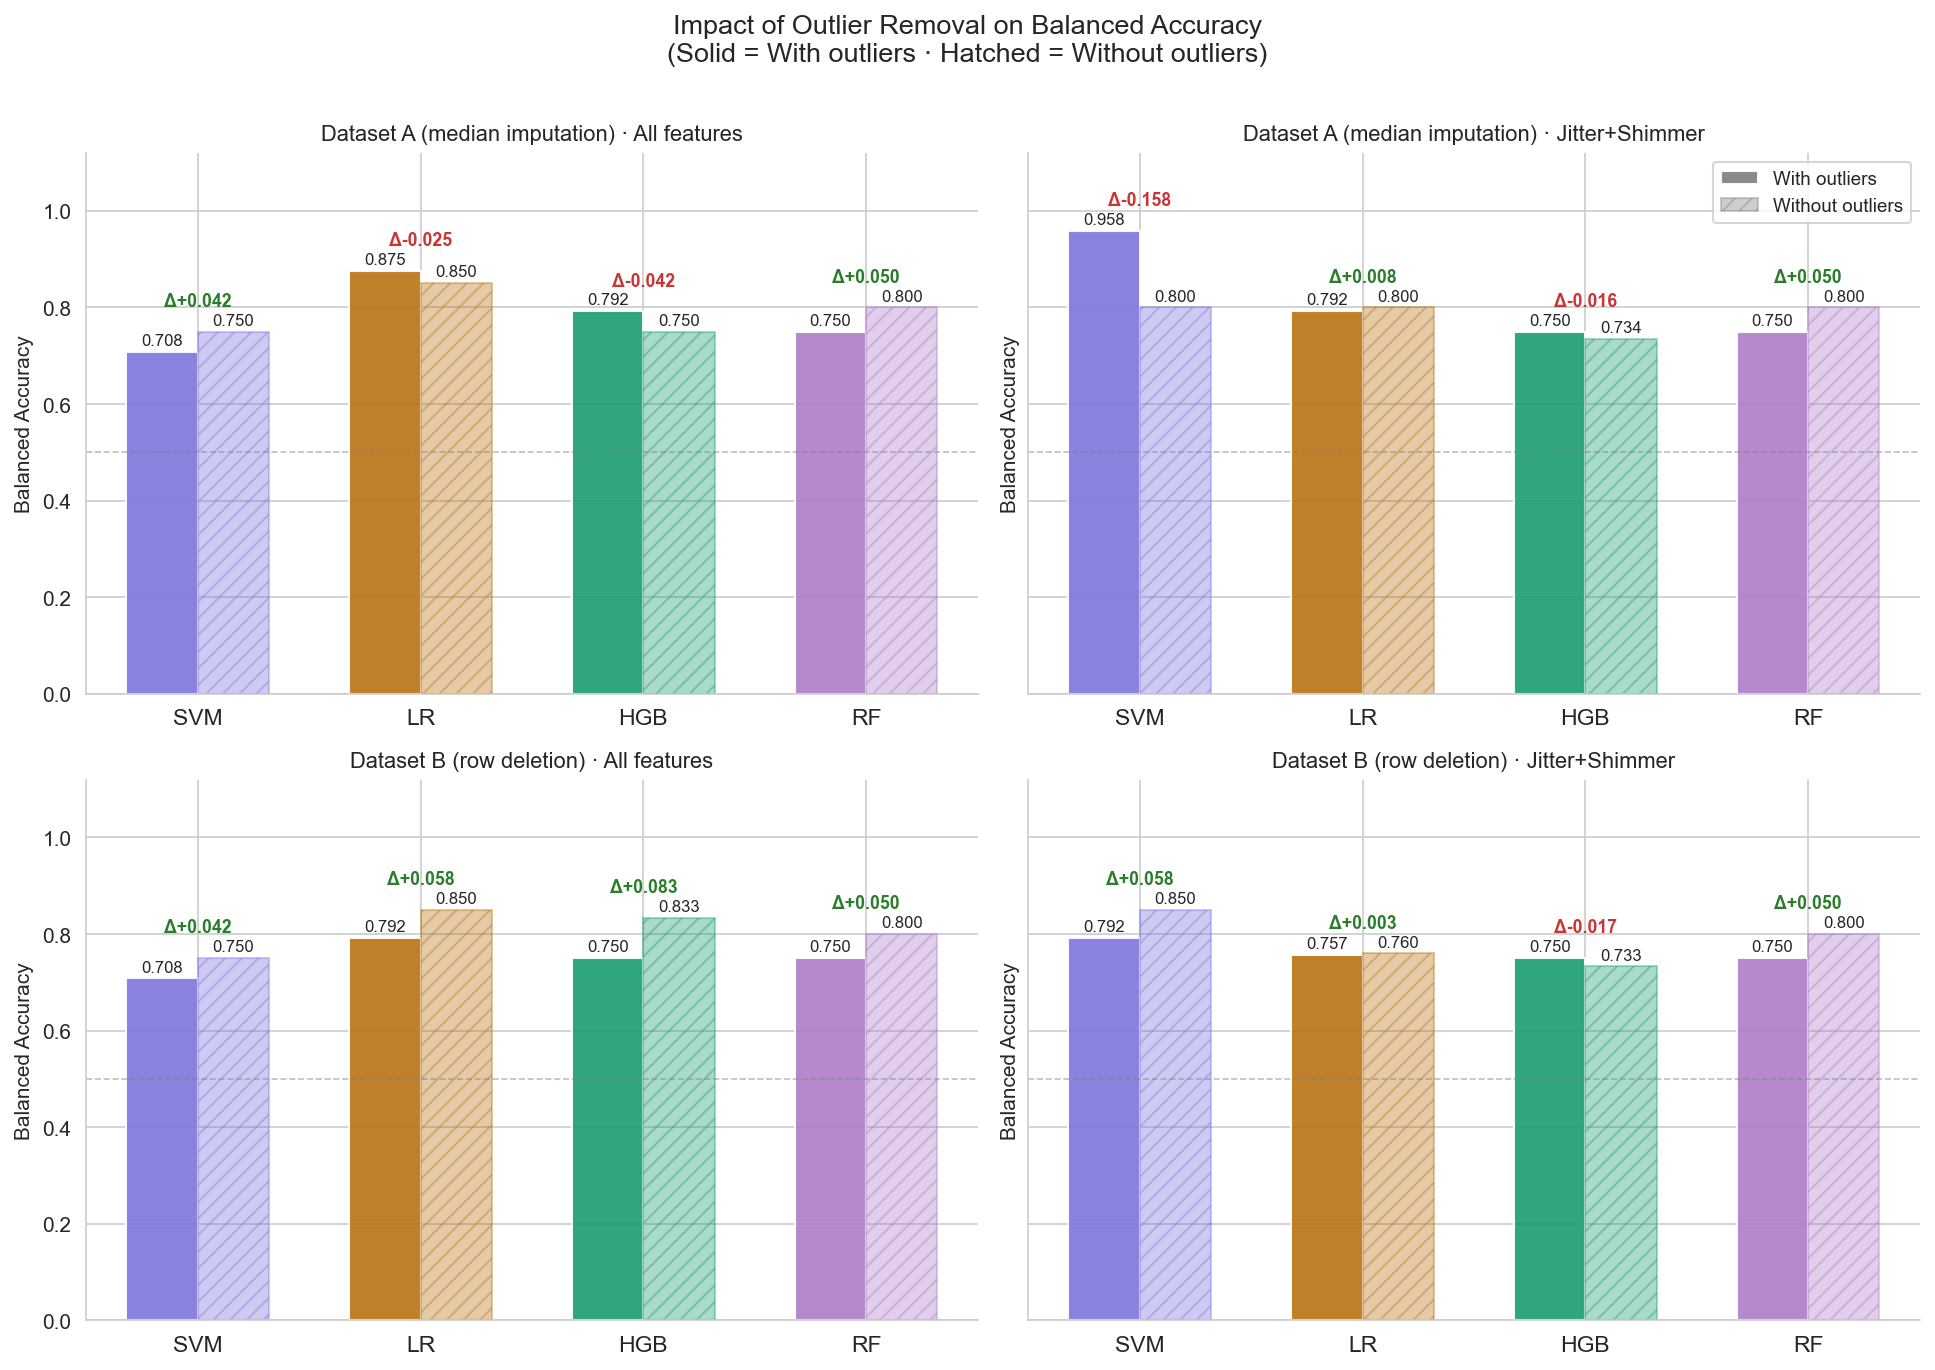

Saved -> plots/outlier_impact_comparison.png


In [12]:
model_order_out = ["SVM", "LR", "HGB", "RF"]
datasets     = ["A", "B"]
feature_sets = ["All", "Jitter+Shimmer"]
feat_labels  = {"All": "All features", "Jitter+Shimmer": "Jitter+Shimmer"}

width = 0.32
x = np.arange(len(model_order_out))

fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharey=True)
fig.suptitle(
    "Impact of Outlier Removal on Balanced Accuracy\n(Solid = With outliers · Hatched = Without outliers)",
    fontsize=13, y=1.01,
)

for row_i, ds in enumerate(datasets):
    for col_i, fs in enumerate(feature_sets):
        ax = axes[row_i][col_i]
        sub = df[(df["Dataset"] == ds) & (df["Feature_Set"] == fs)]

        ba_with    = []
        ba_without = []
        for m in model_order_out:
            w  = sub[(sub["Model"] == m) & (sub["Outliers"] == "With")]["Balanced_Acc"]
            wo = sub[(sub["Model"] == m) & (sub["Outliers"] == "Without")]["Balanced_Acc"]
            ba_with.append(w.values[0]  if len(w)  else np.nan)
            ba_without.append(wo.values[0] if len(wo) else np.nan)

        colors = [PALETTE[m] for m in model_order_out]

        bars_w = ax.bar(
            x - width / 2, ba_with, width,
            color=colors, alpha=0.92, edgecolor="white",
            label="With outliers",
        )
        bars_wo = ax.bar(
            x + width / 2, ba_without, width,
            color=colors, alpha=0.38, hatch="///",
            edgecolor=colors,
            label="Without outliers",
        )

        # value labels
        for bar in bars_w:
            h = bar.get_height()
            if not np.isnan(h):
                ax.text(bar.get_x() + bar.get_width() / 2, h + 0.008,
                        f"{h:.3f}", ha="center", va="bottom", fontsize=8)
        for bar in bars_wo:
            h = bar.get_height()
            if not np.isnan(h):
                ax.text(bar.get_x() + bar.get_width() / 2, h + 0.008,
                        f"{h:.3f}", ha="center", va="bottom", fontsize=8)

        # Δ annotations above each pair
        for xi, (bw, bwo) in enumerate(zip(ba_with, ba_without)):
            if not (np.isnan(bw) or np.isnan(bwo)):
                delta = bwo - bw
                top   = max(bw, bwo) + 0.045
                color = "#2a7d2a" if delta > 0 else ("#cc3333" if delta < 0 else "#555")
                sign  = "+" if delta >= 0 else ""
                ax.text(xi, top, f"Δ{sign}{delta:.3f}",
                        ha="center", va="bottom", fontsize=8.5,
                        color=color, fontweight="bold")

        ax.set_xticks(x)
        ax.set_xticklabels(model_order_out, fontsize=11)
        ax.set_ylim(0, 1.12)
        ax.set_ylabel("Balanced Accuracy", fontsize=10)
        ax.set_title(
            f"Dataset {'A (median imputation)' if ds == 'A' else 'B (row deletion)'}"
            f" · {feat_labels[fs]}",
            fontsize=10.5,
        )
        ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.8, alpha=0.5)
        ax.spines[["top", "right"]].set_visible(False)

        if row_i == 0 and col_i == 1:
            patch_w  = mpatches.Patch(facecolor="grey", alpha=0.92,
                                      label="With outliers")
            patch_wo = mpatches.Patch(facecolor="grey", alpha=0.38, hatch="///",
                                      edgecolor="grey", label="Without outliers")
            ax.legend(handles=[patch_w, patch_wo], fontsize=9, loc="upper right")

plt.tight_layout()
plt.savefig(PLOTS_DIR / "outlier_impact_comparison.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved -> {PLOTS_DIR / 'outlier_impact_comparison.png'}")